#Our goal is to do some text analysis.

The mindset is we've been an execute four different analysis on a pulled corpus of the justifications from humans and large language models immediately elicited after the allocations. Ranked by marginal value to the results section we will have the following:

* treatment language uptake. This is probably the most important valuable piece. That's the only analysis mechanically connects the text channel to the AME gap that we observed in the regressions. That would be, LLMs, echoing the history, prime vocabulary, and presumably human would not this analysis would convert the corpus salient hypothesis from interpretation in a measurement it's cheap and transparent and a review of proof that is there's no black box..

* finally, we will do sentiment analysis, uncertainty, scoring this is a solid match to LENS mechanism, but it is only supporting evidence rather than her result.

Merging datasets

In [ ]:
# =====================================================================
# BLOCK 1 (alternate import): LOCAL UPLOAD INSTEAD OF GITHUB URLS
# Purpose: bypass private-repo raw-URL authentication entirely by
# uploading the two CSVs straight into the Colab session.
# =====================================================================

# --- Step 1: Open the Colab file-upload widget ---------------------
# This pops a file picker; select BOTH CSVs in one go.
from google.colab import files
uploaded = files.upload()   # returns a dict of {filename: bytes}

# --- Step 2: Confirm what arrived ----------------------------------
# Print the filenames so we know both files landed before reading.
print("Uploaded:", list(uploaded.keys()))

# --- Step 3: Read each file by its exact filename ------------------
# Replace the two names below with the printed names from Step 2.
import pandas as pd
df_h = pd.read_csv("human data here")   # human block export
df_l = pd.read_csv("LLM data here")     # canonical seed-307302 LLM export

# --- Step 4: Same inspection as before -----------------------------
print("Human cols:", list(df_h.columns))
print("LLM cols:",   list(df_l.columns))
print("Human rows:", len(df_h), "| LLM rows:", len(df_l))



Saving finalfinaldataLLM.csv to finalfinaldataLLM.csv
Saving IsthereGodhumanusejj.csv to IsthereGodhumanusejj (1).csv
Uploaded: ['finalfinaldataLLM.csv', 'IsthereGodhumanusejj (1).csv']
Human cols: ['IPAddress', 'Duration (in seconds)', 'RecordedDate', 'ResponseId', 'LocationLatitude', 'LocationLongitude', 'PID', 'treatment', 'read timer_First Click', 'read timer_Last Click', 'read timer_Page Submit', 'read timer_Click Count', 'exp timer_First Click', 'exp timer_Last Click', 'exp timer_Page Submit', 'exp timer_Click Count', 'allocate1', 'allocate2', 'allocate3', 'timer token First Click', 'timer token Last Click', 'timer token Page Submit', 'timer token Click Count', 'why', 'timer why First Click', 'timerwhyLast Click', 'timerwhyPage Submit', 'timer whyClick Count', 'mancheck1', 'norms', 'norms timer_First Click', 'norms timer_Last Click', 'norms timer_Page Submit', 'norms timer_Click Count', 'EE1', 'belief timer First Click', 'belief timer Last Click', 'belief timer Page Submit', 'bel

In [ ]:
# --- Diagnostic: what labels does the LLM arm column actually use? --
# Print unique values so we map every one correctly and catch any
# unexpected spelling (e.g. 'science' vs 'cosmo') before mapping.
print("LLM arm unique values:", sorted(df_l["arm"].unique()))


LLM arm unique values: ['control', 'history', 'placebo', 'science']


In [ ]:
# =====================================================================
# BLOCK 1 (COMPLETE, CLEAN REBUILD): IMPORT, HARMONIZE, MERGE
# Purpose: rebuild the merged corpus from the source CSVs with NO
# integer truncation, so the one-decimal LLM allocations survive.
# The previous df in memory was already truncated by an int cast, so
# re-reading from disk is the only way to recover 33.4 from 33.
# =====================================================================

import pandas as pd
import numpy as np

# --- Step 0: Re-read both CSVs fresh from disk ---------------------
# Reading again guarantees we start from the untouched one-decimal
# values, not the truncated copy sitting in memory.
df_h = pd.read_csv("IsthereGodhumanusejj (1).csv")   # human block export
df_l = pd.read_csv("finalfinaldataLLM.csv")          # canonical seed-307302 LLM export

# --- Step 1: Rename human columns to the common schema -------------
# allocate1/2/3 follow instrument display order:
#   allocate1 = Directed, allocate2 = Undirected, allocate3 = Unknowable
rename_h = {
    "PID":       "id",             # Prolific participant identifier
    "allocate1": "directed",       # tokens to Theistic/Directed
    "allocate2": "undirected",     # tokens to Naturalist/Undirected
    "allocate3": "unknowable",     # tokens to Fundamentally Unknowable
    "why":       "justification",  # free-text justification paragraph
}
df_h = df_h.rename(columns=rename_h)

# --- Step 2: Rename LLM columns ------------------------------------
# LLM file already uses directed/undirected/unknowable/justification;
# only the row identifier needs renaming.
df_l = df_l.rename(columns={"draw": "id"})

# --- Step 3: Cross-check the human arm coding (should be diagonal) --
print("Human treatment x arm crosstab:")
print(pd.crosstab(df_h["treatment"], df_h["arm"]))

# --- Step 4: Normalize both arm codings to integers 1-4 ------------
# Human arm is already integer 1-4. LLM arm is text labels; map with
# the same scheme (control=1, science/cosmo=2, placebo=3, history=4).
df_h["arm"] = df_h["arm"].astype(int)
arm_map = {
    "control": 1, "c": 1,
    "cosmo": 2, "science": 2, "cosmological": 2,
    "placebo": 3,
    "history": 4,
}
llm_arm_norm = df_l["arm"].astype(str).str.strip().str.lower()
df_l["arm"] = llm_arm_norm.map(arm_map)
if df_l["arm"].isna().any():                       # fail loudly on any unmapped label
    bad = sorted(llm_arm_norm[df_l["arm"].isna()].unique())
    raise ValueError(f"Unmapped LLM arm labels: {bad} - extend arm_map")
df_l["arm"] = df_l["arm"].astype(int)

# --- Step 4b: Force allocation columns to FLOAT in BOTH frames ------
# THIS IS THE FIX. We explicitly cast to float (never int) so the LLM
# one-decimal values (33.4) are preserved and the human integers (33)
# simply become 33.0. No information is lost either way.
for frame in (df_h, df_l):
    frame[["directed", "undirected", "unknowable"]] = (
        frame[["directed", "undirected", "unknowable"]].astype(float))

# --- Step 5: Add block and model identifiers -----------------------
df_h["block"] = "human"
df_h["model"] = "human"
df_l["block"] = "llm"

# --- Step 6: Stack the two frames on the common schema -------------
# concat of float + float stays float; ignore_index rebuilds 0..1799.
keep = ["id", "block", "arm", "model",
        "directed", "undirected", "unknowable", "justification"]
df = pd.concat([df_h[keep], df_l[keep]], ignore_index=True)

# --- Step 7: Integrity checks (float-aware, no truncation) ---------
# 7a. Total rows.
assert len(df) == 1800, f"Expected 1800 rows, got {len(df)}"
# 7b. Block sizes.
assert df["block"].value_counts().to_dict() == {"llm": 1400, "human": 400}
# 7c. Balance.
print("Rows per block x arm:")
print(pd.crosstab(df["block"], df["arm"]))
# 7d. Sum-to-100 tested as floats with tolerance for binary rounding dust.
sums = df[["directed", "undirected", "unknowable"]].sum(axis=1)
ok = np.isclose(sums, 100.0, atol=1e-6)
assert ok.all(), (f"Allocation-sum violation in {(~ok).sum()} rows; "
                  f"example sums: {sums[~ok].head().tolist()}")
# 7e. Arm codes in range.
assert df["arm"].isin([1, 2, 3, 4]).all(), "Unexpected arm codes"

# --- Step 8: Report (not drop) empty justifications ----------------
n_empty = (df["justification"].isna().sum()
           + (df["justification"].astype(str).str.strip() == "").sum())
print(f"Merged: {len(df)} rows | empty justifications: {n_empty}")

# --- Step 9: Confirm the decimals actually survived ----------------
# Quick proof that the fix worked: show that some allocation cells are
# genuinely fractional now, and that all row sums equal 100.
frac_share = (df[["directed", "undirected", "unknowable"]].values
              % 1 != 0).mean()
print(f"Share of allocation cells with a decimal part: {frac_share:.4f}")
print(f"All row sums == 100 (within tol): {np.isclose(sums, 100.0, atol=1e-6).all()}")


Human treatment x arm crosstab:
arm          1    2    3    4
treatment                    
c          100    0    0    0
cosmo        0  100    0    0
history      0    0    0  100
placebo      0    0  100    0
Rows per block x arm:
arm      1    2    3    4
block                    
human  100  100  100  100
llm    350  350  350  350
Merged: 1800 rows | empty justifications: 1
Share of allocation cells with a decimal part: 0.5685
All row sums == 100 (within tol): True


In [ ]:
# Correct the frozen model-name error (V4 -> V3) in one place, before any
# groupby freezes it into table rows. Assert the expected count so a
# silent miss or an over-broad match fails loudly.
n_before = (df["model"] == "DeepSeek-V4-Flash").sum()
assert n_before == 200, f"Expected 200 DeepSeek rows, found {n_before}"   # 50 draws x 4 arms
df["model"] = df["model"].replace({"DeepSeek-V4-Flash": "DeepSeek-V3-Flash"})
assert (df["model"] == "DeepSeek-V4-Flash").sum() == 0                     # stale label gone
assert (df["model"] == "DeepSeek-V3-Flash").sum() == 200                   # replacement present
print("DeepSeek label corrected: 200 rows V4 -> V3")


DeepSeek label corrected: 200 rows V4 -> V3


In [ ]:
# =====================================================================
# BLOCK 2: PREPROCESSING AND LENGTH COVARIATES
# Purpose: prepare the merged corpus for all four text analyses:
#   (a) drop the one empty justification as a reported exclusion,
#   (b) compute per-document length covariates (word count, TTR) that
#       guard every human-vs-LLM comparison against a trivial
#       "LLMs just write more" explanation,
#   (c) lemmatize uniformly (NOT stem) so dictionary matching in the
#       uptake and hedging analyses treats testimony/testimonies alike.
# Raw text is preserved untouched for the embedding-based steps.
# =====================================================================

import pandas as pd
import numpy as np

# --- Step 1: Drop the single empty justification -------------------
# We agreed empties are REPORTED, then removed here in one visible
# place. Capture N before/after so the subsection can state the
# exclusion exactly, and record which block lost the row.
mask_empty = (df["justification"].isna()
              | (df["justification"].astype(str).str.strip() == ""))
n_before = len(df)
dropped = df.loc[mask_empty, ["block", "arm", "model", "id"]].copy()
df = df.loc[~mask_empty].reset_index(drop=True)   # reset index after the drop
print(f"Dropped {mask_empty.sum()} empty justification(s). "
      f"N: {n_before} -> {len(df)}")
print("Dropped row(s) came from:")
print(dropped.to_string(index=False))
print("Post-drop counts by block:", df["block"].value_counts().to_dict())

# --- Step 2: Normalize text into a working copy --------------------
# 'just_raw' keeps the ORIGINAL text (needed for embeddings, VADER,
# and the stance annotator, all of which want natural text).
# 'just_clean' is lowercased with surrounding whitespace collapsed,
# used only as the input to tokenization/lemmatization.
df["just_raw"] = df["justification"].astype(str)
df["just_clean"] = (df["just_raw"]
                    .str.lower()                       # case-fold
                    .str.replace(r"\s+", " ", regex=True)  # collapse whitespace
                    .str.strip())

# --- Step 3: Simple word count and type-token ratio ----------------
# These are computed on a plain whitespace/alphabetic tokenization so
# they are transparent and model-free (good for the appendix).
# word_count = number of alphabetic tokens.
# ttr = unique tokens / total tokens (lexical diversity).
# NOTE: TTR falls mechanically as length rises, so where we use it as a
# covariate we ALSO include word_count; the two together absorb the
# "LLMs write longer, fuller paragraphs" confound.
import re

def _alpha_tokens(text):
    """Return lowercased alphabetic tokens; digits/punct dropped.
    Used only for the length metrics, not for the analyses themselves."""
    return re.findall(r"[a-z]+", text.lower())

tok_lists = df["just_raw"].apply(_alpha_tokens)          # list of tokens per doc
df["word_count"] = tok_lists.apply(len)                  # total alphabetic tokens
df["ttr"] = tok_lists.apply(
    lambda t: (len(set(t)) / len(t)) if len(t) > 0 else np.nan)  # unique/total

# Report the length asymmetry we are controlling for, by block.
print("\nWord count by block (mean, median):")
print(df.groupby("block")["word_count"].agg(["mean", "median", "min", "max"]))

# --- Step 4: Lemmatize with spaCy (uniform, no stemming) -----------
# spaCy's lemmatizer maps inflected forms to a base form
# (testimonies -> testimony, believed -> believe) without the
# aggressive truncation stemming causes. We disable the parser and NER
# for speed since we only need tagging + lemma.
import spacy
try:
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
except OSError:
    # Model not present in this runtime; download once then load.
    from spacy.cli import download as spacy_download
    spacy_download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def _lemmatize(text):
    """Return a space-joined string of lemmas, lowercased, keeping only
    alphabetic tokens and dropping spaCy stop words. This is the input
    for dictionary-based uptake (Analysis 1) and hedging counts
    (Analysis 4); it is NOT used for embeddings, which want raw text."""
    doc = nlp(text)
    lemmas = [t.lemma_.lower() for t in doc
              if t.is_alpha and not t.is_stop]   # alphabetic, non-stopword
    return " ".join(lemmas)

# nlp.pipe streams the docs in batches, far faster than a Python loop.
df["just_lemma"] = list(nlp.pipe(df["just_clean"].tolist(), batch_size=200))
df["just_lemma"] = [ " ".join(t.lemma_.lower() for t in doc
                              if t.is_alpha and not t.is_stop)
                    for doc in nlp.pipe(df["just_clean"].tolist(), batch_size=200) ]

# --- Step 5: Sanity checks and a look at the result ----------------
# Confirm no lemma field is empty for a non-empty raw doc (would signal
# a doc made entirely of stopwords/punctuation, which we flag not drop).
n_lemma_empty = (df["just_lemma"].str.strip() == "").sum()
print(f"\nDocuments whose lemma string is empty (all stopwords/punct): {n_lemma_empty}")

# Show three examples across the corpus so we can eyeball the pipeline.
print("\nExample raw -> lemma:")
for _, r in df.sample(3, random_state=307302).iterrows():
    print(f"[{r['block']}/{r['model']}] RAW : {r['just_raw'][:120]}")
    print(f"           LEMMA: {r['just_lemma'][:120]}\n")

print("Preprocessing complete. Columns now available:",
      [c for c in df.columns if c.startswith('just') or c in ('word_count','ttr')])


Dropped 1 empty justification(s). N: 1800 -> 1799
Dropped row(s) came from:
block  arm model                       id
human    1 human 695fbf46a18461984feb824f
Post-drop counts by block: {'llm': 1400, 'human': 399}

Word count by block (mean, median):
            mean  median  min  max
block                             
human  45.310777    39.0   10  248
llm    71.965000    66.0   30  177

Documents whose lemma string is empty (all stopwords/punct): 0

Example raw -> lemma:
[llm/Llama-4-Maverick] RAW : I distributed my tokens based on my understanding that the existence of a higher power or purposeful design is a complex
           LEMMA: distribute token base understanding existence high power purposeful design complex debate topic philosopher scientist th

[llm/DeepSeek-V3-Flash] RAW : The scientific evidence for the Big Bang and self-contained physical laws strongly supports an undirected origin, as it 
           LEMMA: scientific evidence big bang self contain physical law strongl

In [ ]:
# =====================================================================
# BLOCK 3a (CORRECTED): DERIVE TREATMENT-UPTAKE DICTIONARIES
# Purpose: build, per treated arm, the set of content lemmas that
# define "echoing this arm's prime," derived mechanically from the
# VERBATIM Table 2 (Panel B) module text via the same spaCy pipeline
# used on the justifications. No hand-picked words. This is the GATE:
# confirm the printed dictionaries before anything downstream runs.
# =====================================================================

# --- Step 1: Verbatim module strings, copied from Table 2 Panel B ---
# These are byte-for-byte the "Exact text presented to participant"
# cells. Control (arm 1) shows no paragraph. The uniform attribution
# line is intentionally EXCLUDED (identical across arms -> non-
# diagnostic; distinctive step would remove it regardless).
MODULE_TEXT = {
    1: "",  # Control: no contextual paragraph
    2: ("Cosmological data and astronomical observations show that our "
        "universe began about 13.8 billion years ago in a rapid expansion "
        "known as the Big Bang, originating from an ultra-dense, "
        "high-temperature initial state."),                          # Arm 2 Cosmological
    3: ("Biological data and microscopic observations show that human red "
        "blood cells circulate for about 120 days before being cleared in a "
        "process called senescence, which begins in a tightly regulated, "
        "oxygen-dependent state."),                                  # Arm 3 Placebo
    4: ("Historical data and textual observations show that records of "
        "antiquity contain thousands of documented attestations across "
        "independent cultures reporting divine encounters and miraculous "
        "events, originating from a recurrent, cross-cultural religious "
        "experience."),                                              # Arm 4 Historical
}
ARM_NAME = {1: "Control", 2: "Cosmological", 3: "Placebo", 4: "Historical"}

# --- Step 2: Lemmatize each module the SAME way as the documents ----
# Reuse the loaded spaCy 'nlp'; same rule as just_lemma (alphabetic,
# non-stopword, lowercased lemmas). Guarantees a module word and a
# document word collapse to the identical token before matching.
def module_lemmas(text):
    """Return the SET of content lemmas in a module string. A set
    because uptake is membership-based: we ask whether a document token
    IS one of the prime's content words; module duplicates add nothing."""
    if not text.strip():
        return set()                      # Control has no vocabulary
    doc = nlp(text.lower())
    return {t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop}

full_dict = {arm: module_lemmas(MODULE_TEXT[arm]) for arm in (2, 3, 4)}

# --- Step 3: Build DISTINCTIVE dictionaries (PRIMARY measure) --------
# For each treated arm, drop any lemma also appearing in EITHER other
# module. What survives is vocabulary unique to that prime; the shared
# scaffold ('data','observation','show','state','begin','originate')
# is removed from all three. Pure set difference: mechanical, no hand
# curation, defensible against a "which words did you pick?" objection.
distinct_dict = {}
for arm in (2, 3, 4):
    others = set().union(*[full_dict[a] for a in (2, 3, 4) if a != arm])
    distinct_dict[arm] = full_dict[arm] - others

# --- Step 4: Print full + distinctive dictionaries for verification -
print("=== FULL content dictionaries (all content lemmas per module) ===")
for arm in (2, 3, 4):
    print(f"[{ARM_NAME[arm]}] ({len(full_dict[arm])}): {sorted(full_dict[arm])}")

print("\n=== DISTINCTIVE dictionaries (arm-specific; PRIMARY uptake set) ===")
for arm in (2, 3, 4):
    print(f"[{ARM_NAME[arm]}] ({len(distinct_dict[arm])}): {sorted(distinct_dict[arm])}")

# --- Step 5: Print the removed scaffold, for transparency -----------
# Words appearing in >=2 modules, treated as non-diagnostic framing.
scaffold = {w for w in set().union(*full_dict.values())
            if sum(w in full_dict[a] for a in (2, 3, 4)) >= 2}
print(f"\n=== Shared scaffold removed as non-diagnostic ({len(scaffold)}) ===")
print(sorted(scaffold))


=== FULL content dictionaries (all content lemmas per module) ===
[Cosmological] (21): ['ago', 'astronomical', 'bang', 'begin', 'big', 'billion', 'cosmological', 'datum', 'dense', 'expansion', 'high', 'initial', 'know', 'observation', 'originate', 'rapid', 'state', 'temperature', 'ultra', 'universe', 'year']
[Placebo] (20): ['begin', 'biological', 'blood', 'call', 'cell', 'circulate', 'clear', 'datum', 'day', 'dependent', 'human', 'microscopic', 'observation', 'oxygen', 'process', 'red', 'regulated', 'senescence', 'state', 'tightly']
[Historical] (23): ['antiquity', 'attestation', 'contain', 'cross', 'cultural', 'culture', 'datum', 'divine', 'document', 'encounter', 'event', 'experience', 'historical', 'independent', 'miraculous', 'observation', 'originate', 'record', 'recurrent', 'religious', 'report', 'textual', 'thousand']

=== DISTINCTIVE dictionaries (arm-specific; PRIMARY uptake set) ===
[Cosmological] (16): ['ago', 'astronomical', 'bang', 'big', 'billion', 'cosmological', 'dense

In [ ]:
# =====================================================================
# BLOCK 3b: COMPUTE PER-DOCUMENT UPTAKE MEASURES
# Purpose: for every justification, quantify how much it echoes its
# arm's prime, via two complementary measures:
#   (M1) distinctive-dictionary hit RATE  -- transparent, model-free,
#        computed on the lemmatized text against the locked dictionaries.
#   (M2) cosine similarity to the module   -- captures numeric/phrase
#        echoes M1 misses, computed on RAW text via sentence embeddings.
# Control-arm docs get every dictionary applied so each arm has a
# measured false-positive base rate for the difference-in-differences.
# =====================================================================

import numpy as np
import pandas as pd

# --- Step 1: Attach each row's OWN-arm distinctive dictionary -------
# 'own_dict' is the set of prime words for the arm the doc was shown.
# Control (arm 1) has an empty prime, so its OWN uptake is undefined;
# we still compute cross-dictionary hits for it below to get base rates.
arm_to_dict = {2: distinct_dict[2], 3: distinct_dict[3], 4: distinct_dict[4]}

# --- Step 2: Tokenize the lemma field once into token lists ---------
# just_lemma is already space-joined content lemmas; split to a list so
# we can count hits and normalize by document length in lemmas.
df["_lemma_tokens"] = df["just_lemma"].str.split()
df["_n_lemma"] = df["_lemma_tokens"].apply(len)   # denominator for hit RATE

def hit_rate(tokens, vocab):
    """Fraction of a document's content lemmas that are in `vocab`.
    Normalizing by document length (not a raw count) prevents the
    longer LLM paragraphs from scoring higher purely by having more
    words. Returns 0.0 for an empty document (none exist post-clean)."""
    if not tokens:
        return 0.0
    hits = sum(1 for t in tokens if t in vocab)
    return hits / len(tokens)

# --- Step 3 (M1): Own-arm distinctive hit rate ---------------------
# For treated arms, score against the arm's own prime dictionary.
# For Control, there is no own prime; leave own-uptake as NaN (Control
# enters the analysis only through cross-dictionary base rates, Step 5).
def own_uptake(row):
    d = arm_to_dict.get(row["arm"])
    if d is None:                 # Control
        return np.nan
    return hit_rate(row["_lemma_tokens"], d)

df["uptake_hit"] = df.apply(own_uptake, axis=1)

# --- Step 4 (M1 cross): every-dictionary hit rates -----------------
# Score EVERY doc against EACH treated arm's dictionary regardless of
# the arm it was shown. This yields, for the Control arm specifically,
# the base rate at which each dictionary fires on prose that saw no
# prime -- the false-positive floor the DiD differences away.
for arm in (2, 3, 4):
    df[f"hit_dict{arm}"] = df["_lemma_tokens"].apply(
        lambda toks, a=arm: hit_rate(toks, distinct_dict[a]))

# --- Step 5 (M2): Embedding cosine similarity to the own module -----
# Model-free measures miss numeric ("13.8 billion") and paraphrastic
# echoes. Cosine similarity between the doc embedding and the OWN-arm
# module embedding captures semantic/near-verbatim overlap on RAW text.
# One encoder for everything, consistent with the plan.
from sentence_transformers import SentenceTransformer
encoder = SentenceTransformer("all-MiniLM-L6-v2")   # single fixed encoder

# 5a. Embed the three module strings once (Control has none -> skip).
module_emb = {arm: encoder.encode(MODULE_TEXT[arm], normalize_embeddings=True)
              for arm in (2, 3, 4)}

# 5b. Embed all documents (raw text) in a batch; normalize so a plain
#     dot product equals cosine similarity.
doc_emb = encoder.encode(df["just_raw"].tolist(),
                         normalize_embeddings=True,
                         batch_size=64, show_progress_bar=True)

# 5c. Cosine of each doc against its OWN-arm module (NaN for Control).
def own_cosine(i, row):
    d = module_emb.get(row["arm"])
    if d is None:
        return np.nan
    return float(np.dot(doc_emb[i], d))

df["uptake_cos"] = [own_cosine(i, r) for i, (_, r) in enumerate(df.iterrows())]

# 5d. Cross-cosine to each treated module, mirroring Step 4, so Control
#     supplies a semantic base rate too.
for arm in (2, 3, 4):
    df[f"cos_dict{arm}"] = doc_emb @ module_emb[arm]

# --- Step 6: Report the two measures by block x arm ----------------
# First look at the mechanism. We expect, for the OWN-arm measures,
# LLM uptake >> human uptake in the treated arms, and the gap largest
# in History.
print("Mean OWN-arm dictionary hit rate (uptake_hit) by block x arm:")
print(df.pivot_table("uptake_hit", "block", "arm", aggfunc="mean").round(4))
print("\nMean OWN-arm cosine (uptake_cos) by block x arm:")
print(df.pivot_table("uptake_cos", "block", "arm", aggfunc="mean").round(4))

# Clean up the bulky helper column but keep token counts for controls.
df.drop(columns=["_lemma_tokens"], inplace=True)
print("\nUptake measures computed. New columns: uptake_hit, uptake_cos, "
      "hit_dict2-4, cos_dict2-4, _n_lemma")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

Mean OWN-arm dictionary hit rate (uptake_hit) by block x arm:
arm         2       3       4
block                        
human  0.1031  0.0234  0.0263
llm    0.0822  0.0783  0.1508

Mean OWN-arm cosine (uptake_cos) by block x arm:
arm         2       3       4
block                        
human  0.2989  0.0625  0.2327
llm    0.4261  0.2270  0.5613

Uptake measures computed. New columns: uptake_hit, uptake_cos, hit_dict2-4, cos_dict2-4, _n_lemma


In [ ]:
# =====================================================================
# BLOCK 3c: THREE UPTAKE TESTS
# (T1) Block gap within each treated arm  -- Mann-Whitney, both measures
# (T2) DiD: is the LLM-over-human uptake gap LARGER in History than in
#      Placebo?  This is the PRIMARY statistic; Placebo differences away
#      generic-jargon echoing so only origin-relevant echo survives.
# (T3) Within LLM History cell, does per-doc uptake predict the Directed
#      share?  Links the text channel to the allocation result directly.
# All inference nonparametric or bootstrap, seed 307302, matching the
# EE-subsection style. Length (word_count, ttr) enters T3 as controls.
# =====================================================================

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
rng = np.random.default_rng(307302)          # single fixed seed

ARM_NAME = {2: "Cosmological", 3: "Placebo", 4: "Historical"}

# --- T1: Block gap within each treated arm -------------------------
# For each arm and each measure, compare LLM vs human uptake with a
# Mann-Whitney U (rank-based, no normality assumption). Report the U,
# the p-value, and a rank-biserial effect size for interpretability.
def mw(a, b):
    """Mann-Whitney U with rank-biserial effect size r = 1 - 2U2/(n1 n2)."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    U, p = mannwhitneyu(a, b, alternative="two-sided")
    rb = 1 - (2 * U) / (len(a) * len(b))       # effect size in [-1, 1]
    return U, p, rb, a.mean(), b.mean()

print("=== T1: LLM vs human uptake within each treated arm ===")
for measure in ("uptake_hit", "uptake_cos"):
    print(f"\n-- measure: {measure} --")
    for arm in (2, 3, 4):
        sub = df[df["arm"] == arm]
        U, p, rb, m_llm, m_hum = mw(sub.loc[sub.block=="llm",  measure],
                                    sub.loc[sub.block=="human", measure])
        print(f"[{ARM_NAME[arm]:12}] LLM={m_llm:.4f} human={m_hum:.4f} "
              f"U={U:.0f} p={p:.3g} rank-biserial={rb:+.3f}")

# --- T2: Difference-in-differences (PRIMARY) -----------------------
# Define the block gap in an arm as mean_LLM(uptake) - mean_human(uptake).
# DiD = gap(History) - gap(Placebo). Placebo is the negative control:
# both blocks may echo authoritative jargon there, so subtracting the
# Placebo gap isolates echoing that is specific to origin-relevant
# (History) content. Inference by nonparametric bootstrap: resample
# within each block x arm cell, recompute the DiD, 5,000 times.
def block_gap(frame, arm, measure):
    s = frame[frame.arm == arm]
    return (s.loc[s.block=="llm",  measure].mean()
            - s.loc[s.block=="human", measure].mean())

def did_point(frame, measure):
    return block_gap(frame, 4, measure) - block_gap(frame, 3, measure)

def did_bootstrap(measure, B=5000):
    """Bootstrap the History-minus-Placebo DiD by resampling rows within
    each of the four relevant block x arm cells independently."""
    cells = {(b, a): df[(df.block==b) & (df.arm==a)].index.to_numpy()
             for b in ("llm", "human") for a in (3, 4)}
    obs = did_point(df, measure)
    boot = np.empty(B)
    for i in range(B):
        idx = np.concatenate([rng.choice(v, size=len(v), replace=True)
                              for v in cells.values()])
        boot[i] = did_point(df.loc[idx], measure)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    p2 = 2 * min((boot <= 0).mean(), (boot >= 0).mean())   # two-sided
    return obs, lo, hi, p2

print("\n=== T2: History-minus-Placebo DiD in the LLM-over-human uptake gap ===")
for measure in ("uptake_hit", "uptake_cos"):
    obs, lo, hi, p = did_bootstrap(measure)
    print(f"[{measure}] DiD={obs:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  "
          f"boot p={p:.4g}")

# --- T3: Does uptake predict the Directed share, in LLM History? ----
# Restrict to the cell where the allocation effect lives (LLM, arm 4).
# Regress Directed SHARE (0-1) on uptake, controlling for length so the
# link is not a byproduct of longer, fuller paragraphs. OLS point
# estimates with bootstrap SEs (percentile), seed 307302. Framing note
# for prose: within a single generative pass the justification is
# produced alongside the allocation, so this is internal-consistency
# evidence that the echo and the number move together, not causal
# recovery.
import statsmodels.api as sm

cell = df[(df.block=="llm") & (df.arm==4)].copy()
cell["directed_share"] = cell["directed"] / 100.0     # to [0,1]

def ols_boot(y, X, B=5000):
    """OLS betas with percentile-bootstrap SEs and 95% CIs."""
    Xc = sm.add_constant(X)
    beta = np.linalg.lstsq(Xc.values, y.values, rcond=None)[0]
    idx = np.arange(len(y))
    boots = np.empty((B, Xc.shape[1]))
    for i in range(B):
        s = rng.choice(idx, size=len(idx), replace=True)
        boots[i] = np.linalg.lstsq(Xc.values[s], y.values[s], rcond=None)[0]
    se = boots.std(0, ddof=1)
    lo, hi = np.percentile(boots, [2.5, 97.5], axis=0)
    return Xc.columns, beta, se, lo, hi

for measure in ("uptake_hit", "uptake_cos"):
    X = cell[[measure, "word_count", "ttr"]]
    names, beta, se, lo, hi = ols_boot(cell["directed_share"], X)
    print(f"\n=== T3: Directed share on {measure} + length (LLM History) ===")
    for n, b, s, l, h in zip(names, beta, se, lo, hi):
        print(f"  {n:12} beta={b:+.4f} se={s:.4f} 95%CI[{l:+.4f},{h:+.4f}]")


=== T1: LLM vs human uptake within each treated arm ===

-- measure: uptake_hit --
[Cosmological] LLM=0.0822 human=0.1031 U=16878 p=0.588 rank-biserial=+0.036
[Placebo     ] LLM=0.0783 human=0.0234 U=28934 p=6.77e-24 rank-biserial=-0.653
[Historical  ] LLM=0.1508 human=0.0263 U=32618 p=7.26e-40 rank-biserial=-0.864

-- measure: uptake_cos --
[Cosmological] LLM=0.4261 human=0.2989 U=26345 p=1.24e-14 rank-biserial=-0.505
[Placebo     ] LLM=0.2270 human=0.0625 U=25856 p=3.21e-13 rank-biserial=-0.477
[Historical  ] LLM=0.5613 human=0.2327 U=33664 p=4.19e-45 rank-biserial=-0.924

=== T2: History-minus-Placebo DiD in the LLM-over-human uptake gap ===
[uptake_hit] DiD=+0.0697  95% CI [+0.0515, +0.0877]  boot p=0
[uptake_cos] DiD=+0.1641  95% CI [+0.1257, +0.2039]  boot p=0

=== T3: Directed share on uptake_hit + length (LLM History) ===
  const        beta=+0.4154 se=0.0788 95%CI[+0.2642,+0.5721]
  uptake_hit   beta=+0.3137 se=0.0765 95%CI[+0.1601,+0.4597]
  word_count   beta=-0.0008 se=0.000

In [ ]:
# =====================================================================
# BLOCK 3d: TRIPLE DIFFERENCE (ROBUSTNESS FOR T2)
# Purpose: armor the primary DiD. The two-way DiD compared the
# LLM-over-human uptake gap in History vs Placebo. The triple
# difference ADDITIONALLY subtracts each block's Control-arm base rate
# before differencing, removing any arm-invariant background echoing
# (e.g., a block's generic tendency to use dictionary words in ordinary
# prose with no prime present). What survives is uptake attributable
# specifically to exposure to origin-relevant content.
#
# Construction, step by step:
#   1. base(block)      = mean cross-dictionary hit in CONTROL for that
#                         block, using the History dict for the History
#                         term and the Placebo dict for the Placebo term
#                         (Control docs saw no prime, so any "hits" are
#                         pure false-positive background).
#   2. adj_gap(arm)     = [LLM uptake(arm) - LLM base] -
#                         [human uptake(arm) - human base]
#   3. DDD              = adj_gap(History) - adj_gap(Placebo)
# Inference: same cell-wise bootstrap as T2, now resampling SIX cells
# (2 blocks x {Control, Placebo, History}), 5,000 draws, seed 307302.
# =====================================================================

import numpy as np

rng = np.random.default_rng(307302)     # fresh generator, same seed policy

# --- Step 1: define the measure pairs ------------------------------
# For the dictionary measure, the Control base rate for the History
# term uses hit_dict4 (History dictionary applied to Control docs) and
# for the Placebo term uses hit_dict3. Same logic for cosine.
MEASURES = {
    "hit":  {"treated": "uptake_hit", 3: "hit_dict3", 4: "hit_dict4"},
    "cos":  {"treated": "uptake_cos", 3: "cos_dict3", 4: "cos_dict4"},
}

def ddd_point(frame, spec):
    """Compute the triple difference on a (possibly resampled) frame."""
    out = {}
    for arm in (3, 4):
        # Treated-arm own uptake, by block.
        t = frame[frame.arm == arm]
        up_llm = t.loc[t.block == "llm",  spec["treated"]].mean()
        up_hum = t.loc[t.block == "human", spec["treated"]].mean()
        # Control-arm base rate for THIS arm's dictionary, by block.
        c = frame[frame.arm == 1]
        base_llm = c.loc[c.block == "llm",  spec[arm]].mean()
        base_hum = c.loc[c.block == "human", spec[arm]].mean()
        # Base-adjusted block gap for this arm.
        out[arm] = (up_llm - base_llm) - (up_hum - base_hum)
    return out[4] - out[3]              # History minus Placebo

def ddd_bootstrap(spec, B=5000):
    """Cell-wise bootstrap over the six block x arm cells involved."""
    cells = {(b, a): df[(df.block == b) & (df.arm == a)].index.to_numpy()
             for b in ("llm", "human") for a in (1, 3, 4)}
    obs = ddd_point(df, spec)
    boot = np.empty(B)
    for i in range(B):
        idx = np.concatenate([rng.choice(v, size=len(v), replace=True)
                              for v in cells.values()])
        boot[i] = ddd_point(df.loc[idx], spec)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    p2 = 2 * min((boot <= 0).mean(), (boot >= 0).mean())
    # Report bootstrap-resolution floor rather than a literal zero.
    p_str = f"<{2/B:.4f}" if p2 == 0 else f"{p2:.4f}"
    return obs, lo, hi, p_str

# --- Step 2: also print the ingredients, for the table -------------
# The manuscript table shows the reader every layer: raw cell means,
# block gaps, base rates, adjusted gaps, then the final DDD. Printing
# them here gives us the exact numbers the table will carry.
print("=== Ingredients (dictionary hit-rate measure) ===")
for b in ("llm", "human"):
    c = df[(df.block == b) & (df.arm == 1)]
    print(f"  {b:5} Control base: dict3={c['hit_dict3'].mean():.4f} "
          f"dict4={c['hit_dict4'].mean():.4f}")
for arm in (3, 4):
    t = df[df.arm == arm]
    print(f"  arm {arm}: LLM={t.loc[t.block=='llm','uptake_hit'].mean():.4f} "
          f"human={t.loc[t.block=='human','uptake_hit'].mean():.4f}")

print("\n=== Ingredients (cosine measure) ===")
for b in ("llm", "human"):
    c = df[(df.block == b) & (df.arm == 1)]
    print(f"  {b:5} Control base: cos3={c['cos_dict3'].mean():.4f} "
          f"cos4={c['cos_dict4'].mean():.4f}")
for arm in (3, 4):
    t = df[df.arm == arm]
    print(f"  arm {arm}: LLM={t.loc[t.block=='llm','uptake_cos'].mean():.4f} "
          f"human={t.loc[t.block=='human','uptake_cos'].mean():.4f}")

# --- Step 3: run the triple difference on both measures ------------
print("\n=== TRIPLE DIFFERENCE: base-adjusted History-minus-Placebo gap ===")
for name, spec in MEASURES.items():
    obs, lo, hi, p = ddd_bootstrap(spec)
    print(f"[{name}] DDD={obs:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  boot p={p}")


=== Ingredients (dictionary hit-rate measure) ===
  llm   Control base: dict3=0.0107 dict4=0.0047
  human Control base: dict3=0.0069 dict4=0.0100
  arm 3: LLM=0.0783 human=0.0234
  arm 4: LLM=0.1508 human=0.0263

=== Ingredients (cosine measure) ===
  llm   Control base: cos3=0.0135 cos4=0.2448
  human Control base: cos3=0.0417 cos4=0.1948
  arm 3: LLM=0.2270 human=0.0625
  arm 4: LLM=0.5613 human=0.2327

=== TRIPLE DIFFERENCE: base-adjusted History-minus-Placebo gap ===
[hit] DDD=+0.0788  95% CI [+0.0594, +0.0986]  boot p=<0.0004
[cos] DDD=+0.0858  95% CI [+0.0406, +0.1309]  boot p=0.0004


VADER sentimetn analysis

In [ ]:
# =====================================================================
# BLOCK 4: SENTIMENT AND CERTAINTY (ANALYSIS 4)
# Purpose: the LENS mechanism check. Score each justification for
#   (a) sentiment valence  -- VADER compound score on RAW text
#   (b) hedging intensity  -- Hyland-style hedge terms per 100 words,
#       a transparent, model-free certainty proxy
# LENS-consistent prediction: human scores are invariant to treatment
# arm (convictions anchor tone), while LLM scores track the module.
# Tests mirror the EE subsection style:
#   - Kruskal-Wallis ACROSS arms WITHIN each block (treatment response)
#   - Mann-Whitney BETWEEN blocks WITHIN each arm (block gap)
# =====================================================================

import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu

# --- Step 1: VADER sentiment on raw text ---------------------------
# VADER is lexicon-based (no training, no seed), designed for short
# text, and returns a compound score in [-1, +1]. We install if absent.
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "vaderSentiment"], check=True)
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()
# Compound score per document; raw text, since VADER uses punctuation
# and capitalization as intensity cues that lemmatization destroys.
df["sentiment"] = df["just_raw"].apply(
    lambda t: vader.polarity_scores(t)["compound"])

# --- Step 2: Hedging rate (certainty proxy) ------------------------
# Hyland-style hedge inventory: epistemic verbs, adverbs, and modal
# constructions signaling reduced commitment. Matched on the LEMMA
# field so inflections collapse (seems/seemed -> seem). Rate is hedges
# per 100 content lemmas, normalizing away the block length gap.
HEDGES = {
    "perhaps", "maybe", "possibly", "likely", "unlikely", "probably",
    "seem", "appear", "suggest", "indicate", "assume", "speculate",
    "might", "may", "could", "presumably", "arguably", "conceivably",
    "uncertain", "unclear", "unsure", "possibility", "probability",
    "tend", "roughly", "somewhat", "relatively", "plausible",
}
# NOTE: spaCy marks 'might/may/could' as stopwords, so they were
# stripped from just_lemma. We therefore count hedges on the CLEAN
# (lowercased, unlemmatized) text tokens instead, and lemmatize the
# match targets crudely by including base forms above. Transparent and
# reproducible; the appendix lists the inventory verbatim.
import re
def hedge_rate(text):
    """Hedge tokens per 100 words on the cleaned lowercase text."""
    toks = re.findall(r"[a-z]+", text)
    if not toks:
        return np.nan
    hits = sum(1 for t in toks if t in HEDGES)
    return 100.0 * hits / len(toks)

df["hedge_rate"] = df["just_clean"].apply(hedge_rate)

# --- Step 3: Descriptives by block x arm ---------------------------
print("Mean sentiment (VADER compound) by block x arm:")
print(df.pivot_table("sentiment", "block", "arm", aggfunc="mean").round(4))
print("\nMean hedge rate (per 100 words) by block x arm:")
print(df.pivot_table("hedge_rate", "block", "arm", aggfunc="mean").round(4))

# --- Step 4: Kruskal-Wallis across arms within block ---------------
# Tests whether the measure RESPONDS TO TREATMENT at all, per block.
# LENS-consistent: significant for LLM, null for human.
print("\n=== KW across arms, within block ===")
for measure in ("sentiment", "hedge_rate"):
    for b in ("human", "llm"):
        groups = [df[(df.block == b) & (df.arm == a)][measure].dropna()
                  for a in (1, 2, 3, 4)]
        H, p = kruskal(*groups)
        print(f"[{measure:10}] {b:5}: H={H:.2f} p={p:.3g}")

# --- Step 5: Mann-Whitney between blocks within arm ----------------
# Documents the block gap per arm; sign convention fixed so POSITIVE
# rank-biserial means LLM HIGHER (the T1 table's readability fix).
print("\n=== MW between blocks, within arm (rb>0 means LLM higher) ===")
for measure in ("sentiment", "hedge_rate"):
    for a in (1, 2, 3, 4):
        x = df[(df.block == "llm") & (df.arm == a)][measure].dropna()
        y = df[(df.block == "human") & (df.arm == a)][measure].dropna()
        U, p = mannwhitneyu(x, y, alternative="two-sided")
        rb = (2 * U) / (len(x) * len(y)) - 1     # >0 iff LLM ranks higher
        print(f"[{measure:10}] arm {a}: LLM={x.mean():+.3f} "
              f"human={y.mean():+.3f} p={p:.3g} rb={rb:+.3f}")


Mean sentiment (VADER compound) by block x arm:
arm         1       2       3      4
block                               
human  0.2436  0.2683  0.2765  0.254
llm    0.4324  0.4180  0.4269  0.499

Mean hedge rate (per 100 words) by block x arm:
arm         1       2       3       4
block                                
human  0.6610  0.9084  0.9967  0.9223
llm    0.9626  0.7981  0.6792  1.3734

=== KW across arms, within block ===
[sentiment ] human: H=0.12 p=0.989
[sentiment ] llm  : H=10.84 p=0.0126
[hedge_rate] human: H=2.71 p=0.438
[hedge_rate] llm  : H=59.54 p=7.37e-13

=== MW between blocks, within arm (rb>0 means LLM higher) ===
[sentiment ] arm 1: LLM=+0.432 human=+0.244 p=6e-05 rb=+0.264
[sentiment ] arm 2: LLM=+0.418 human=+0.268 p=0.000298 rb=+0.237
[sentiment ] arm 3: LLM=+0.427 human=+0.277 p=0.000298 rb=+0.237
[sentiment ] arm 4: LLM=+0.499 human=+0.254 p=9.56e-07 rb=+0.321
[hedge_rate] arm 1: LLM=+0.963 human=+0.661 p=0.000365 rb=+0.213
[hedge_rate] arm 2: LLM=+0.798 hum

Saved: fig_sentiment_hedging.pdf


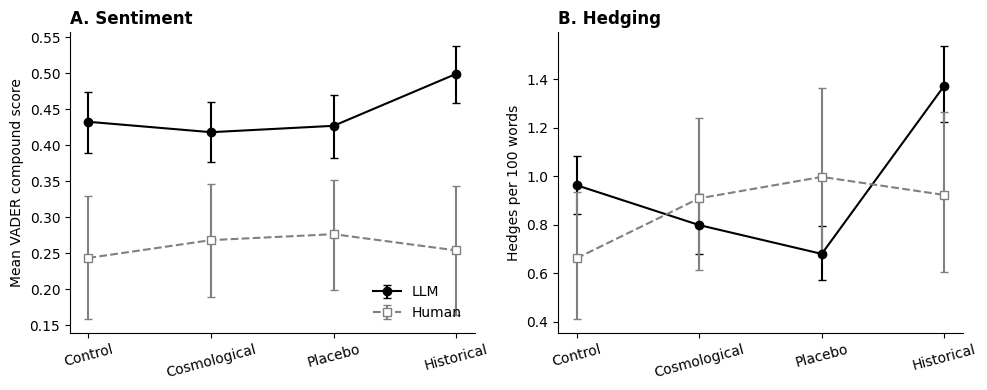

In [ ]:
# =====================================================================
# BLOCK 4b: VADER / HEDGING VISUALIZATION
# Purpose: one two-panel figure for the manuscript.
#   Panel A: mean VADER compound sentiment by arm, one line per block
#   Panel B: mean hedge rate by arm, one line per block
# Visual argument: the HUMAN line is flat across arms (tone anchored),
# the LLM line moves with the module (register tracks context). Error
# bars are 95% bootstrap CIs (5,000 draws, seed 307302) so the figure's
# inference matches the subsection's nonparametric style.
# Output: uptake-ready PDF (vector, grayscale-legible) for \includegraphics.
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(307302)          # same single-seed policy

ARM_LABELS = ["Control", "Cosmological", "Placebo", "Historical"]
ARMS = [1, 2, 3, 4]

def boot_ci(vals, B=5000):
    """Percentile bootstrap 95% CI for a mean. Returns (mean, lo, hi)."""
    v = np.asarray(vals.dropna(), float)
    means = np.empty(B)
    for i in range(B):
        means[i] = rng.choice(v, size=len(v), replace=True).mean()
    return v.mean(), *np.percentile(means, [2.5, 97.5])

def series(block, measure):
    """Mean and CI per arm for one block x measure, ready to plot."""
    m, lo, hi = [], [], []
    for a in ARMS:
        mm, l, h = boot_ci(df[(df.block == block) & (df.arm == a)][measure])
        m.append(mm); lo.append(mm - l); hi.append(h - mm)   # asymmetric bars
    return np.array(m), np.array(lo), np.array(hi)

# --- Build the figure ----------------------------------------------
# Two panels side by side; shared x (arms). Styling kept austere:
# no gridlines beyond light y, no color dependence (line styles +
# markers differ so grayscale printing preserves the contrast).
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
x = np.arange(len(ARMS))

SPECS = [("sentiment",  "Mean VADER compound score", "A. Sentiment"),
         ("hedge_rate", "Hedges per 100 words",       "B. Hedging")]

for ax, (measure, ylab, title) in zip(axes, SPECS):
    # LLM series: solid line, filled circles.
    m, lo, hi = series("llm", measure)
    ax.errorbar(x, m, yerr=[lo, hi], fmt="-o", capsize=3,
                color="black", label="LLM")
    # Human series: dashed line, open squares -> distinct in grayscale.
    m, lo, hi = series("human", measure)
    ax.errorbar(x, m, yerr=[lo, hi], fmt="--s", capsize=3,
                color="gray", markerfacecolor="white", label="Human")
    ax.set_xticks(x, ARM_LABELS, rotation=15)
    ax.set_ylabel(ylab)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)   # de-junk
axes[0].legend(frameon=False, loc="lower right")

fig.tight_layout()
fig.savefig("fig_sentiment_hedging.pdf", bbox_inches="tight")  # vector for LaTeX
print("Saved: fig_sentiment_hedging.pdf")
plt.show()


Saved: fig_sentiment_hedging_violins.pdf


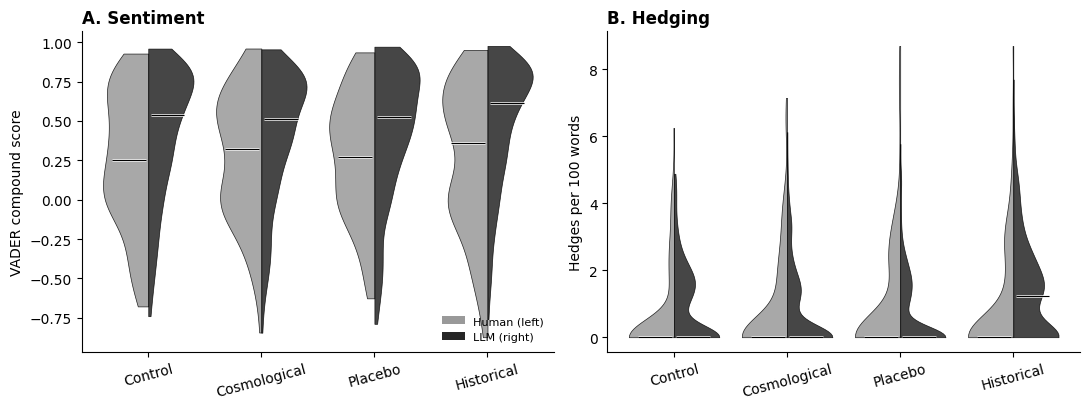

In [ ]:
# =====================================================================
# BLOCK 4c: APPENDIX VIOLINS FOR SENTIMENT AND HEDGING
# Purpose: distributional companion to the means figure. Split violins
# per arm (human left half, LLM right half) for
#   Panel A: VADER compound sentiment
#   Panel B: hedge rate (per 100 words)
# Visual argument the means figure cannot make: the HUMAN distribution
# is wide and essentially identical across arms (anchored heterogeneity)
# while the LLM distribution is tighter and MOVES with the module.
# Output: vector PDF for the appendix.
# =====================================================================

import numpy as np
import matplotlib.pyplot as plt

ARM_LABELS = ["Control", "Cosmological", "Placebo", "Historical"]
ARMS = [1, 2, 3, 4]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)

SPECS = [("sentiment",  "VADER compound score",  "A. Sentiment"),
         ("hedge_rate", "Hedges per 100 words",  "B. Hedging")]

for ax, (measure, ylab, title) in zip(axes, SPECS):
    for i, a in enumerate(ARMS):
        # Pull the two block distributions for this arm.
        hv = df[(df.block == "human") & (df.arm == a)][measure].dropna().values
        lv = df[(df.block == "llm")   & (df.arm == a)][measure].dropna().values

        # Draw each block as a HALF-violin at the same x position:
        # human on the left half (gray), LLM on the right half (black).
        for vals, side, color in ((hv, "low", "0.6"), (lv, "high", "0.15")):
            parts = ax.violinplot([vals], positions=[i], widths=0.8,
                                  showextrema=False)
            body = parts["bodies"][0]
            # Clip the violin body to one side of the center line so the
            # two blocks share an x position without overplotting.
            verts = body.get_paths()[0].vertices
            if side == "low":
                verts[:, 0] = np.minimum(verts[:, 0], i)   # keep left half
            else:
                verts[:, 0] = np.maximum(verts[:, 0], i)   # keep right half
            body.set_facecolor(color)
            body.set_alpha(0.85)
            body.set_edgecolor("black")
            body.set_linewidth(0.5)

        # Overlay medians as short horizontal ticks, one per half, so the
        # central tendency is readable without a boxplot's clutter.
        ax.hlines(np.median(hv), i - 0.32, i - 0.02, color="white", lw=1.8)
        ax.hlines(np.median(hv), i - 0.32, i - 0.02, color="black", lw=0.8)
        ax.hlines(np.median(lv), i + 0.02, i + 0.32, color="white", lw=1.8)
        ax.hlines(np.median(lv), i + 0.02, i + 0.32, color="black", lw=0.8)

    ax.set_xticks(range(len(ARMS)), ARM_LABELS, rotation=15)
    ax.set_ylabel(ylab)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

# Manual legend (violinplot creates no handles): gray = human (left
# halves), near-black = LLM (right halves).
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor="0.6", label="Human (left)"),
                        Patch(facecolor="0.15", label="LLM (right)")],
               frameon=False, loc="lower right", fontsize=8)

fig.tight_layout()
fig.savefig("fig_sentiment_hedging_violins.pdf", bbox_inches="tight")
print("Saved: fig_sentiment_hedging_violins.pdf")
plt.show()
